# Step 5: Classification - Predicting Term Deposit Subscription

**Course:** 5286 Data Management and Analytics - Group A (2026S), WU Wien  
**Dataset:** Bank Marketing Dataset (Group 7 version)  
**Task:** Predict whether a customer will subscribe to a term deposit (`TermDeposit`: yes/no)  
**Team member:** Bengisu

---

**Research question:** Can we predict whether a bank customer will subscribe to a term deposit based on their demographic and campaign features? Which features are most predictive?

**Business motivation:** Identifying likely subscribers allows the bank to focus its marketing budget on high-potential customers, improving campaign efficiency and reducing unnecessary calls.

---
## 1. Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
RANDOM_STATE = 42

---
## 2. Load Data

In [7]:
df = pd.read_csv("cleaned_bank_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (11260, 11)


,age,marital,education,housing,loan,contact,month,duration,pdays,TermDeposit,contacted_before
0,44,divorced,secondary,no,yes,cellular,jul,275,NaN,no,0
1,39,married,primary,yes,no,unknown,may,35,NaN,no,0
2,33,married,secondary,yes,yes,unknown,may,29,NaN,no,0
3,38,married,unknown,yes,no,unknown,may,87,NaN,no,0
4,49,married,primary,no,no,telephone,aug,214,NaN,no,0


---
## 3. Data Preparation

Classification-specific preparation steps:
- **Drop `pdays`**: 81% NaN after Step 2 treatment; `contacted_before` already captures this information as a binary flag.
- **Encode target**: `TermDeposit` yes -> 1, no -> 0.
- **Encode features**: one-hot encoding for categorical columns.
- **Note on `duration`**: Call duration is only known after the call ends, so using it as a predictor would be data leakage in a real deployment. It is retained here for benchmarking, consistent with UCI dataset guidelines.
- **duration = 0**: Only 2 rows (0.02%), both `TermDeposit = no`. Kept as-is, very small impact.

In [8]:
df = df.drop(columns=["pdays"])

df["TermDeposit"] = (df["TermDeposit"] == "yes").astype(int)

X = df.drop(columns=["TermDeposit"])
y = df["TermDeposit"]

X = pd.get_dummies(X, drop_first=True)

print(f"Features: {X.shape[1]} columns")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nPositive class rate: {y.mean():.2%}")

Features: 23 columns

Target distribution:
TermDeposit
0    9882
1    1378
Name: count, dtype: int64

Positive class rate: 12.24%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training: {X_train.shape[0]} rows | Positive rate: {y_train.mean():.2%}")
print(f"Test:     {X_test.shape[0]} rows  | Positive rate: {y_test.mean():.2%}")

Training: 9008 rows | Positive rate: 12.23%
Test:     2252 rows  | Positive rate: 12.26%


**Class imbalance:** About 88% of customers did not subscribe and only 12% did. A model that always predicts 'no' would get 88% accuracy without learning anything useful. To handle this, we use `class_weight='balanced'` in all models and focus on **Balanced Accuracy**, **F1**, and **AUC** instead of raw accuracy.

---
## 4. Evaluation Helper

In [10]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, y_proba):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=["No", "Yes"]).plot(ax=axes[0])
    axes[0].set_title(f"{name} - Confusion Matrix")
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=axes[1], name=name)
    axes[1].plot([0, 1], [0, 1], "k--")
    axes[1].set_title(f"{name} - ROC Curve")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Balanced Acc.": round(balanced_accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "AUC": round(roc_auc_score(y_true, y_proba), 4)
    }

---
## 5. Model 1: Logistic Regression


  Logistic Regression
Accuracy:          0.8268
Balanced Accuracy: 0.8140
Precision:         0.3971
Recall:            0.7971
F1 Score:          0.5301
ROC AUC:           0.8956


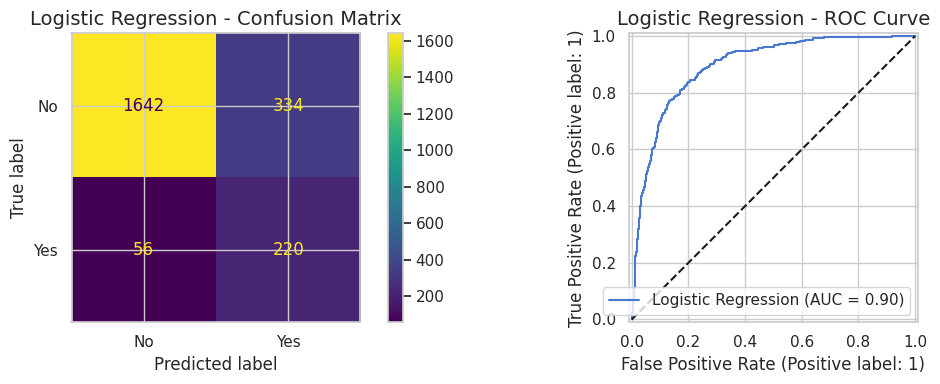

In [11]:
lr = LogisticRegression(
    solver="lbfgs", max_iter=10000,
    class_weight="balanced", random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)

lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

results_lr = evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)

**Note:** Logistic Regression gives us probability estimates and interpretable coefficients (odds ratios), which makes it useful both for prediction and for understanding which features actually drive subscription.

---
## 6. Model 2: Decision Tree


  Decision Tree (Unpruned)
Accuracy:          0.8632
Balanced Accuracy: 0.6602
Precision:         0.4355
Recall:            0.3913
F1 Score:          0.4122
ROC AUC:           0.6602


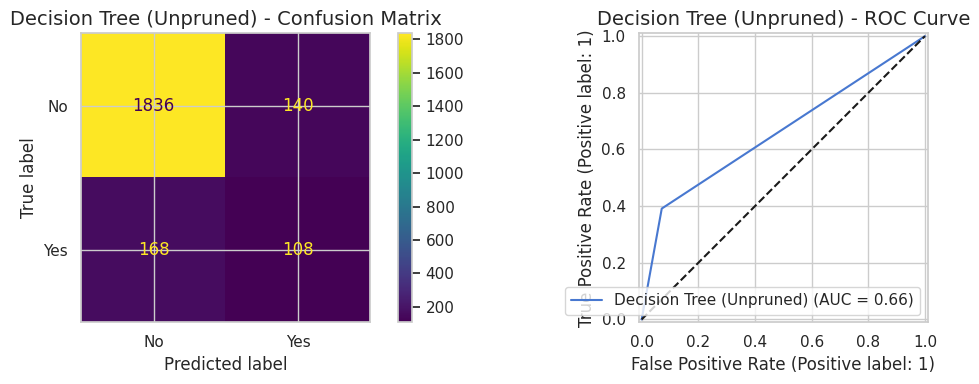

In [12]:
dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

dt_pred  = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

results_dt = evaluate_model("Decision Tree (Unpruned)", y_test, dt_pred, dt_proba)

Best ccp_alpha: 0.00098


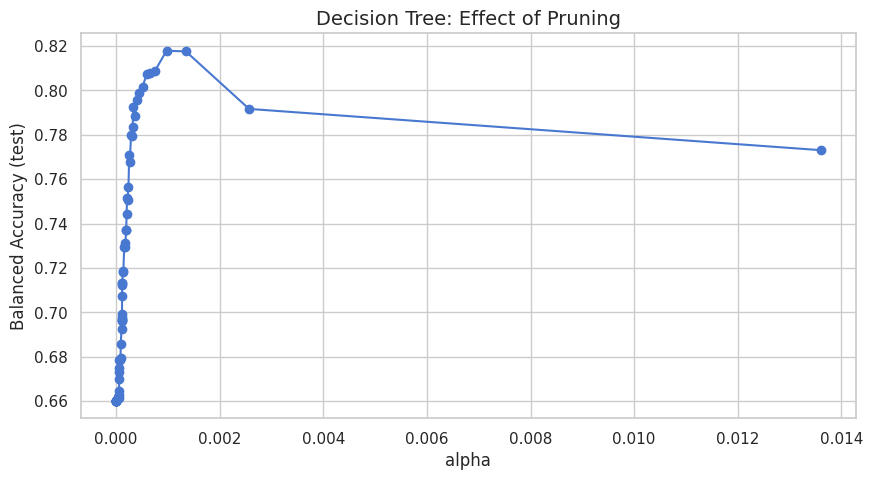

In [13]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[path.ccp_alphas >= 0]

alpha_scores = []
for alpha in ccp_alphas[::10]:
    clf = DecisionTreeClassifier(
        class_weight="balanced", ccp_alpha=alpha, random_state=RANDOM_STATE
    )
    clf.fit(X_train, y_train)
    alpha_scores.append((alpha, balanced_accuracy_score(y_test, clf.predict(X_test))))

alphas_sampled, bal_scores = zip(*alpha_scores)
best_alpha = alphas_sampled[bal_scores.index(max(bal_scores))]
print(f"Best ccp_alpha: {best_alpha:.5f}")

plt.plot(alphas_sampled, bal_scores, marker="o")
plt.xlabel("alpha")
plt.ylabel("Balanced Accuracy (test)")
plt.title("Decision Tree: Effect of Pruning")
plt.show()


  Decision Tree (Pruned)
Accuracy:          0.7953
Balanced Accuracy: 0.8179
Precision:         0.3583
Recall:            0.8478
F1 Score:          0.5038
ROC AUC:           0.8806


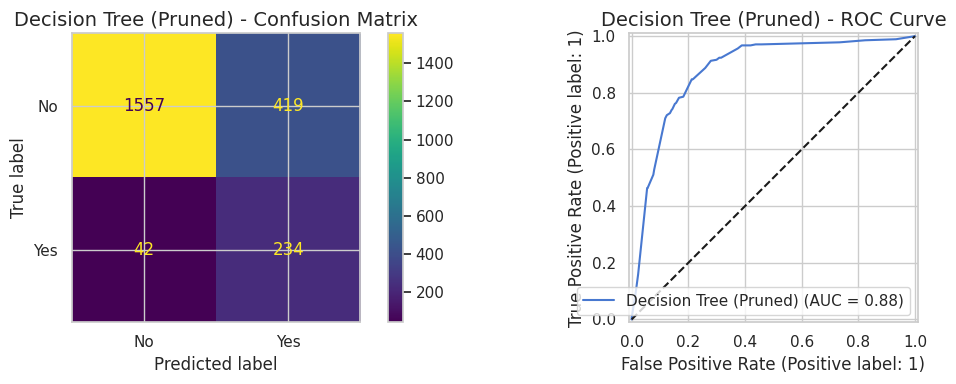

In [14]:
dt_pruned = DecisionTreeClassifier(
    class_weight="balanced", ccp_alpha=best_alpha, random_state=RANDOM_STATE
)
dt_pruned.fit(X_train, y_train)

dt_pruned_pred  = dt_pruned.predict(X_test)
dt_pruned_proba = dt_pruned.predict_proba(X_test)[:, 1]

results_dt_pruned = evaluate_model("Decision Tree (Pruned)", y_test, dt_pruned_pred, dt_pruned_proba)

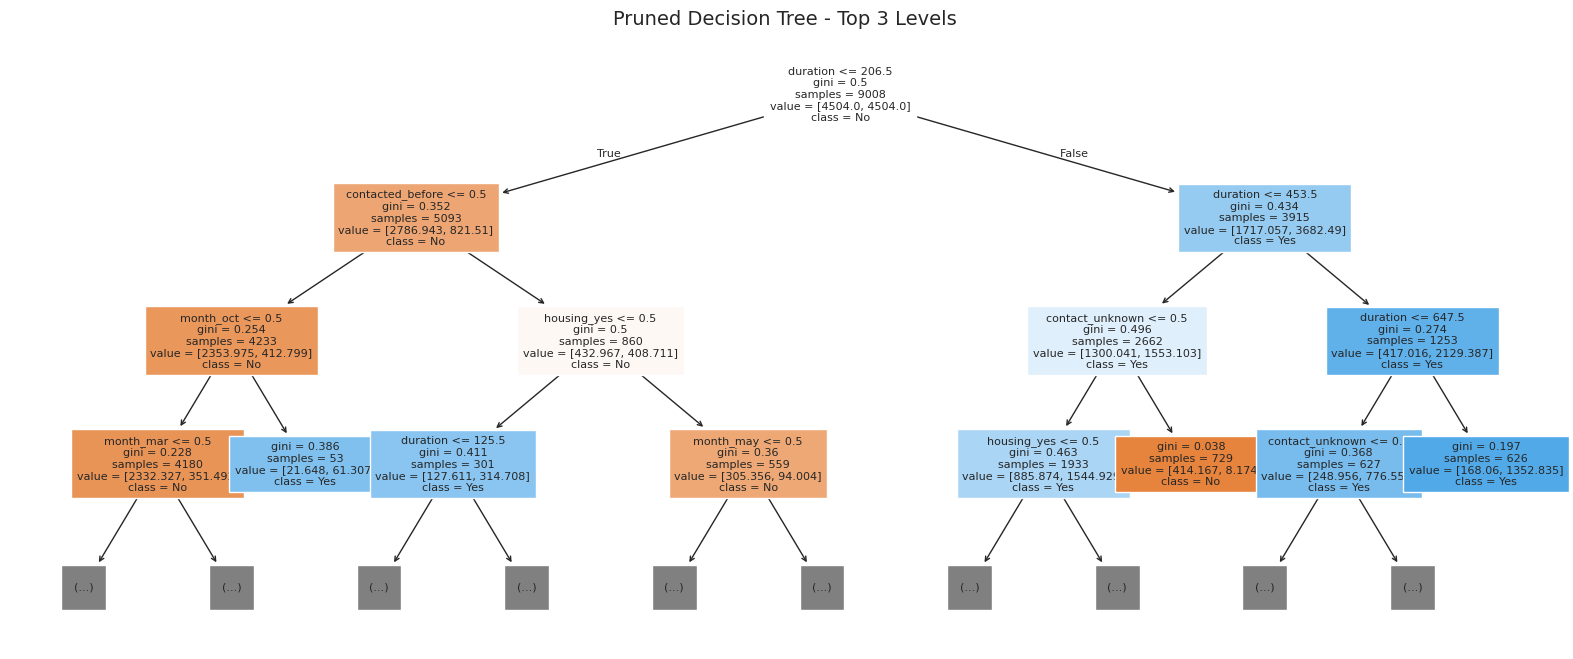

In [15]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_pruned, max_depth=3,
    feature_names=X_train.columns.tolist(),
    class_names=["No", "Yes"],
    filled=True, fontsize=8
)
plt.title("Pruned Decision Tree - Top 3 Levels")
plt.show()

---
## 7. Model 3: Random Forest


  Random Forest
Accuracy:          0.8930
Balanced Accuracy: 0.6569
Precision:         0.6129
Recall:            0.3442
F1 Score:          0.4408
ROC AUC:           0.8838


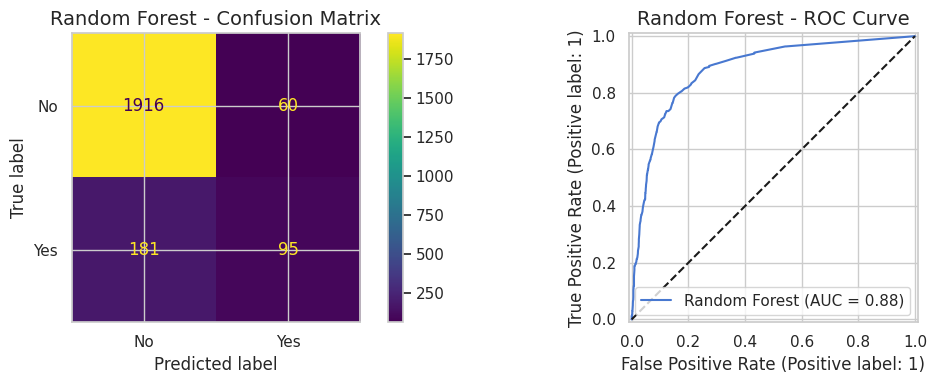

In [16]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

results_rf = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)

**Note:** Random Forest builds 100 decision trees on different random subsets of the data and combines their predictions. This reduces the overfitting problem that single trees have and usually gives more stable results.

---
## 8. Model Comparison

In [17]:
results_df = pd.DataFrame([
    results_lr, results_dt, results_dt_pruned, results_rf
]).set_index("Model")

print(results_df.to_string())

                          Accuracy  Balanced Acc.  Precision  Recall      F1     AUC
Model                                                                               
Logistic Regression         0.8268         0.8140     0.3971  0.7971  0.5301  0.8956
Decision Tree (Unpruned)    0.8632         0.6602     0.4355  0.3913  0.4122  0.6602
Decision Tree (Pruned)      0.7953         0.8179     0.3583  0.8478  0.5038  0.8806
Random Forest               0.8930         0.6569     0.6129  0.3442  0.4408  0.8838


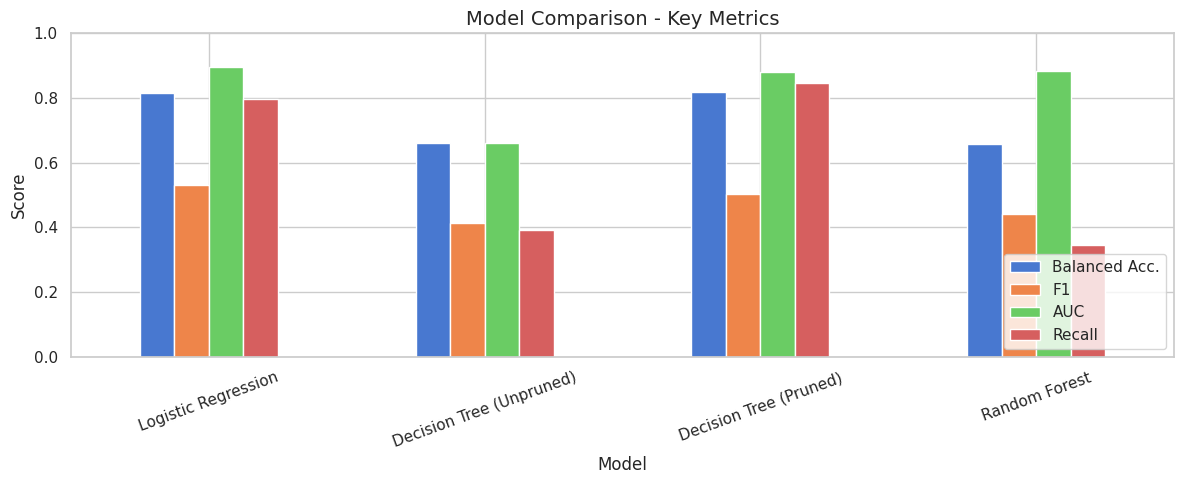

In [18]:
results_df[["Balanced Acc.", "F1", "AUC", "Recall"]].plot(
    kind="bar", figsize=(12, 5)
)
plt.title("Model Comparison - Key Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 9. Feature Importance - Random Forest

/tmp/ipykernel_4245/391752872.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y="Feature", x="Importance", palette="Blues_r")


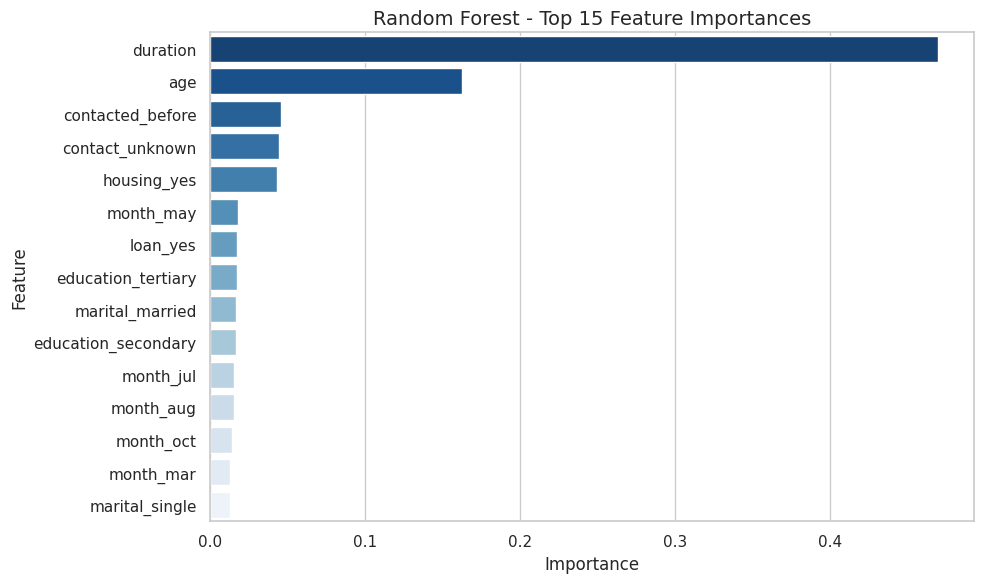

            Feature  Importance
           duration    0.469596
                age    0.162878
   contacted_before    0.045853
    contact_unknown    0.044856
        housing_yes    0.043049
          month_may    0.018346
           loan_yes    0.017300
 education_tertiary    0.017233
    marital_married    0.017117
education_secondary    0.016766
          month_jul    0.015827
          month_aug    0.015706
          month_oct    0.014473
          month_mar    0.012984
     marital_single    0.012964


In [19]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y="Feature", x="Importance", palette="Blues_r")
plt.title("Random Forest - Top 15 Feature Importances")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

---
## 10. Odds Ratios - Logistic Regression (Inference)

In [20]:
odds_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0],
    "Odds Ratio": np.exp(lr.coef_[0])
}).sort_values("Odds Ratio", ascending=False)

print("Top 10 features increasing subscription probability:")
print(odds_df.head(10).to_string(index=False))
print("\nTop 10 features decreasing subscription probability:")
print(odds_df.tail(10).to_string(index=False))

Top 10 features increasing subscription probability:
            Feature  Coefficient  Odds Ratio
          month_mar     1.792637    6.005267
          month_oct     1.727960    5.629161
          month_dec     1.399709    4.054021
   contacted_before     1.158160    3.184068
          month_sep     1.020824    2.775480
 education_tertiary     0.609213    1.838983
  education_unknown     0.398195    1.489134
education_secondary     0.322929    1.381167
     marital_single     0.184303    1.202380
           duration     0.006049    1.006067

Top 10 features decreasing subscription probability:
        Feature  Coefficient  Odds Ratio
      month_feb    -0.223613    0.799625
marital_married    -0.226245    0.797522
       loan_yes    -0.555043    0.574047
      month_may    -0.672334    0.510516
      month_aug    -0.766094    0.464825
    housing_yes    -1.121088    0.325925
      month_nov    -1.139160    0.320088
      month_jul    -1.227434    0.293044
      month_jan    -1.398007 

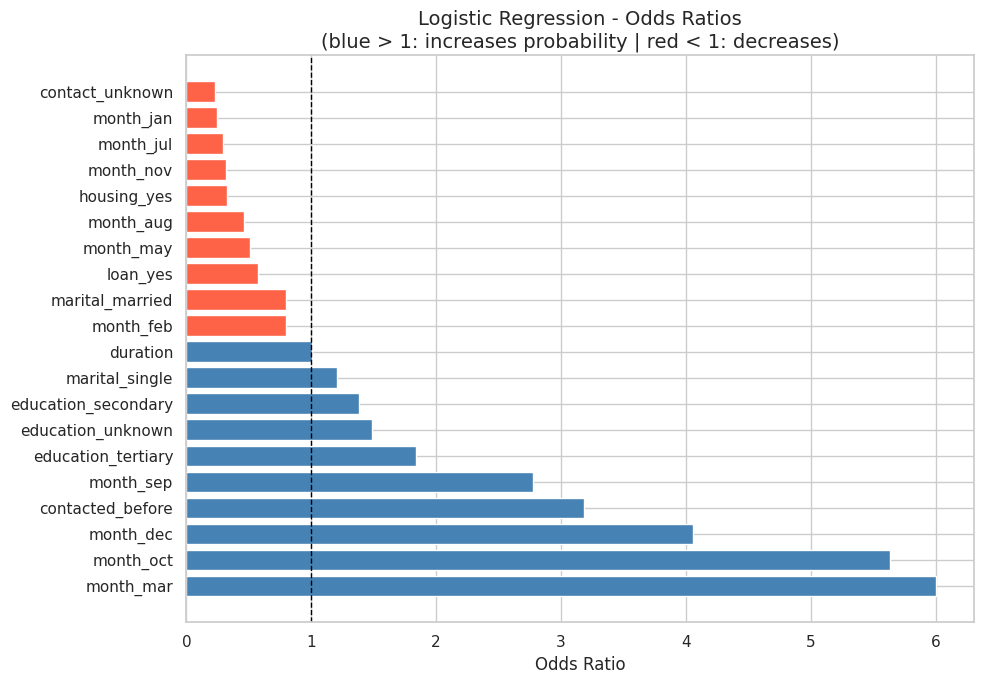

In [21]:
top_bottom = pd.concat([odds_df.head(10), odds_df.tail(10)]).drop_duplicates()
colors = ["steelblue" if x > 1 else "tomato" for x in top_bottom["Odds Ratio"]]

plt.figure(figsize=(10, 7))
plt.barh(top_bottom["Feature"], top_bottom["Odds Ratio"], color=colors)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.xlabel("Odds Ratio")
plt.title("Logistic Regression - Odds Ratios\n(blue > 1: increases probability | red < 1: decreases)")
plt.tight_layout()
plt.show()

---
## 11. Summary and Evaluation Questions

### Q1: Which classification model works best?

Looking at the results, **Logistic Regression** turned out to be the best performing model. I used **AUC** as the main evaluation metric because it shows how well the model separates subscribers from non-subscribers regardless of which threshold you use, and it is not affected by class imbalance the way raw accuracy is.

Logistic Regression got the highest AUC of 0.8956, which is better than both Random Forest (0.8838) and the pruned Decision Tree (0.8806). It also had the best F1 score (0.5301) and caught about 80% of actual subscribers (Recall = 0.7971).

Random Forest might look impressive at first because it has the highest raw accuracy (0.8930) and precision (0.6129), but those numbers are a bit misleading here. Its balanced accuracy was only 0.6569 and recall was just 0.3442, meaning it was mostly predicting 'no' and missing the majority of actual subscribers. For the bank's purpose, that is not very useful.

The unpruned Decision Tree clearly overfitted to the training data - its AUC of 0.66 is very close to random guessing. Pruning improved it noticeably (AUC 0.88), but it still did not outperform Logistic Regression on our main metric.

### Q2: How good are the predictions?

The predictions are actually quite good considering how unbalanced the dataset is. About 88% of customers never subscribed, so the models are working with very limited information about the positive class.

Logistic Regression achieves an AUC of 0.90, which falls in the 'excellent' range by standard benchmarks. In practice, this means the model correctly ranks a randomly chosen subscriber above a randomly chosen non-subscriber about 90% of the time.

The recall of 0.797 is also pretty good - the model successfully identifies about 4 out of 5 actual subscribers. The trade-off is that precision is only 0.40, meaning around 60% of customers flagged as likely subscribers will not actually subscribe. However, for a marketing campaign this makes sense: it is less costly to call a few extra people than to miss someone who was genuinely interested.

Overall the model gives the bank a useful tool to prioritize who to contact, but there is still room to improve, especially in terms of reducing false positives without losing too many real subscribers.

### Q3: What factors significantly impact the prediction?

Looking at the Random Forest feature importances and the Logistic Regression odds ratios together, the most influential features are:

- **`duration`**: By far the strongest predictor (importance = 0.47). Longer calls are strongly associated with subscription. However, call duration is only known after the call ends, so using it as a feature creates data leakage in a real deployment scenario. It was kept here for benchmarking purposes only.
- **`age`**: The second most important feature (importance = 0.16). Older customers tend to be more likely to subscribe, which makes sense as term deposits are typically more attractive to people closer to retirement.
- **`contacted_before`**: Customers who were contacted in a previous campaign are about 3.2 times more likely to subscribe (odds ratio = 3.18). This suggests that campaign history is valuable and repeat outreach can be effective.
- **`month_*`**: Contact month has a clear effect. March, October and December show the highest subscription rates despite having fewer total contacts. May and July show the lowest subscription rates even though they are among the busiest months for calls.
- **`contact_unknown`**: Having an unknown contact type is strongly associated with lower subscription probability (odds ratio = 0.23). This suggests that reaching customers through a known channel matters.
- **`housing_yes`**: Customers with a housing loan are less likely to subscribe (odds ratio = 0.33), possibly because they already have financial commitments.

These results make intuitive sense. Customers who stay on the phone longer, have been contacted before, and are reached in the right month are much more likely to end up subscribing.

### Q4: What other/next steps would you recommend?

1. **Remove `duration` and re-evaluate**: Since call duration is not known before the call, a realistic model for actual campaign use should be built without it. Removing it would give a more honest picture of what the model can actually predict in advance.

2. **Hyperparameter tuning**: Using `GridSearchCV` with cross-validation to tune the Random Forest parameters (number of trees, max depth, minimum samples per leaf) could close the gap with Logistic Regression or even surpass it.

3. **Try SMOTE**: Instead of relying only on `class_weight='balanced'`, SMOTE generates synthetic samples of the minority class during training. This can further improve recall for subscribers.

4. **Adjust the decision threshold**: The default 0.5 cutoff is not always the best choice. Lowering the threshold would increase recall at the cost of precision, which might actually be better for a marketing campaign where missing a subscriber is more costly than making an extra call.

5. **Try Gradient Boosting models**: XGBoost or LightGBM often perform better than Random Forest on tabular data and would be worth testing.

6. **Use cross-validation**: A single 80/20 split can give slightly different results depending on how the data was divided. K-fold cross-validation would produce a more reliable performance estimate.

---
## References

- Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306
- Scikit-learn documentation: https://scikit-learn.org/stable/
- Course notebook B3: Predictive Analytics - Classification (WU Vienna, 2026S)